In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time

##### 1. Using NetworkX and the appropriate graph structure, implement the underlying graph structure represented by these two game boards, taking into account the attributes of the nodes and edges. What types of graphs are involved ?

In [14]:
G = nx.Graph()
G.add_edges_from([
    ('Regents Park', 'Kings Cross', {'weight': 3}),
    ('Regents Park', 'Baker Street', {'weight': 2}),
    ('Regents Park', 'British Museum', {'weight': 3}),
    ('Kings Cross', 'British Museum', {'weight': 2}),
    ('Kings Cross', 'The Charterhouse', {'weight': 3}),
    ('Baker Street', 'British Museum', {'weight': 4}),
    ('Baker Street', 'Hyde Park', {'weight': 4}),
    ('Baker Street', 'Piccadilly Circus', {'weight': 4}),
    ('British Museum', 'Piccadilly Circus', {'weight': 2}),
    ('British Museum', 'Covent Garden', {'weight': 1}),
    ('British Museum', 'Covent Garden', {'weight': 1}),
    ('British Museum', 'The Charterhouse', {'weight': 4}),
    ('The Charterhouse', 'Brick Lane', {'weight': 3}),
    ('Hyde Park', 'Piccadilly Circus', {'weight': 2}),
    ('Hyde Park', 'Piccadilly Circus', {'weight': 2}),
    ('Hyde Park', 'Buckinham Palace', {'weight': 2}),
    ('Piccadilly Circus', 'Buckinham Palace', {'weight': 2}),
    ('Piccadilly Circus', 'Covent Garden', {'weight': 1}),
    ('Piccadilly Circus', 'Covent Garden', {'weight': 1}),
    ('Piccadilly Circus', 'Trafalgar Square', {'weight': 1}),
    ('Piccadilly Circus', 'Trafalgar Square', {'weight': 1}),
    ('Trafalgar Square', 'Buckinham Palace', {'weight': 2}),
    ('Trafalgar Square', 'Big Ben', {'weight': 1}),
    ('Trafalgar Square', 'Waterloo', {'weight': 2}),
    ('Trafalgar Square', 'Covent Garden', {'weight': 1}),
    ('Trafalgar Square', 'Covent Garden', {'weight': 1}),
    ('St Pauls', 'Covent Garden', {'weight': 3}),
    ('St Pauls', 'Covent Garden', {'weight': 3}),
    ('St Pauls', 'The Charterhouse', {'weight': 1}),
    ('St Pauls', 'Brick Lane', {'weight': 3}),
    ('St Pauls', 'Tower of London', {'weight': 3}),
    ('St Pauls', 'Tower of London', {'weight': 3}),
    ('St Pauls', 'Globe Theatre', {'weight': 1}),
    ('St Pauls', 'Globe Theatre', {'weight': 1}),
    ('Globe Theatre', 'Tower of London', {'weight': 3}),
    ('Globe Theatre', 'Waterloo', {'weight': 2}),
    ('Globe Theatre', 'Elephant & Castle', {'weight': 2}),
    ('Big Ben', 'Buckinham Palace', {'weight': 2}),
    ('Big Ben', 'Waterloo', {'weight': 4}),
    ('Big Ben', 'Elephant & Castle', {'weight': 3}),
    ('Elephant & Castle', 'Tower of London', {'weight': 4}),
    ('Elephant & Castle', 'Waterloo', {'weight': 4})
    ])

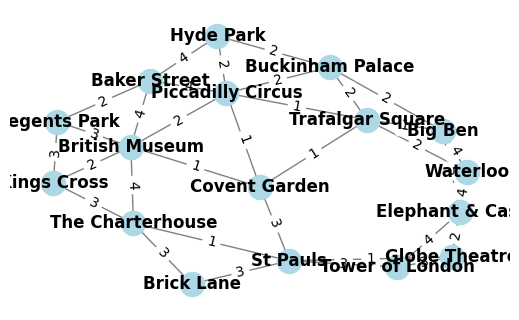

In [40]:
# Generate positions for nodes
pos = nx.spring_layout(G)

# Plot the graph
plt.figure(figsize=(5, 3))
nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold', edge_color='gray')

# Draw edge labels for weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

##### 2. Determine the order and size of these graphs

In [16]:
print(f"Order = {G.order()}")
print(f"Size = {G.size()}")


Order = 17
Size = 34


Order = The number of vertices (nodes) in the graph
Size = The number of edges in the graph

##### 3. Show both graphs as adjacency lists

In [ ]:
for node in G.nodes():
    neighbors = [(nbr, G[node][nbr]['weight']) for nbr in G[node]]
    print(f"{node}: {neighbors}")

Regents Park: [('Kings Cross', 3), ('Baker Street', 2), ('British Museum', 3)]
Kings Cross: [('Regents Park', 3), ('British Museum', 2), ('The Charterhouse', 3)]
Baker Street: [('Regents Park', 2), ('British Museum', 4), ('Hyde Park', 4), ('Piccadilly Circus', 4)]
British Museum: [('Regents Park', 3), ('Kings Cross', 2), ('Baker Street', 4), ('Piccadilly Circus', 2), ('Covent Garden', 1), ('The Charterhouse', 4)]
The Charterhouse: [('Kings Cross', 3), ('British Museum', 4), ('Brick Lane', 3), ('St Pauls', 1)]
Hyde Park: [('Baker Street', 4), ('Piccadilly Circus', 2), ('Buckinham Palace', 2)]
Piccadilly Circus: [('Baker Street', 4), ('British Museum', 2), ('Hyde Park', 2), ('Buckinham Palace', 2), ('Covent Garden', 1), ('Trafalgar Square', 1)]
Covent Garden: [('British Museum', 1), ('Piccadilly Circus', 1), ('Trafalgar Square', 1), ('St Pauls', 3)]
Brick Lane: [('The Charterhouse', 3), ('St Pauls', 3)]
Buckinham Palace: [('Hyde Park', 2), ('Piccadilly Circus', 2), ('Trafalgar Square', 2

Adjacency list = A way to represent a graph where each node lists the nodes it connects to (and possibly edge weights).

##### 4. Determine and display the adjacency, incidence and Laplacian matrices of these graphs

Adjacency matrix (A) = A square matrix 𝑛×𝑛 (where 𝑛 = number of nodes). The elements of the matrix indicate whether pairs of vertices are adjacent or not in the graph.

In [18]:
# Order nodes for consistent matrix representation
nodes = list(G.nodes())

# --- Adjacency Matrix ---
A = nx.to_numpy_array(G, nodelist=nodes, weight="weight")
print("Adjacency Matrix (A):")
print(A)

Adjacency Matrix (A):
[[0. 3. 2. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [3. 0. 0. 2. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [2. 0. 0. 4. 0. 4. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [3. 2. 4. 0. 4. 0. 2. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 3. 0. 4. 0. 0. 0. 0. 3. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 4. 0. 0. 0. 2. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 4. 2. 0. 2. 0. 1. 0. 2. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 3. 0. 0. 0.]
 [0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 2. 0. 0. 0. 2. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 2. 0. 1. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 1. 0. 4. 0. 0. 0. 3.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 4. 0. 0. 0. 2. 4.]
 [0. 0. 0. 0. 1. 0. 0. 3. 3. 0. 0. 0. 0. 0. 3. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 3. 4.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 1. 3. 0. 2.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 4. 0. 4. 2. 0.]]


The incidence matrix of an undirected graph is a nxm matrix B, where n and m are the numbers of vertices and edges respectively, such that Bi,j = 1 if the vertex vi and edge ej are incident, 2 if ej is a loop and 0 otherwise.

In [30]:
B = nx.incidence_matrix(G, nodelist=nodes).todense()
print("\nIncidence Matrix (B):")
print(B)


Incidence Matrix (B):
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 

This is a nxn with n the order (number of vertices) of the graph The coecients of the diagonal are the degrees of the vertices of the graph The coecients of the row i and column j are 1 if the vertices i and j are linked by an edge, and 0 otherwise

In [32]:
K = nx.laplacian_matrix(G, nodelist=nodes).todense()
print("\nLaplacian Matrix (K):")
print(K)


Laplacian Matrix (K):
[[ 8 -3 -2 -3  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [-3  8  0 -2 -3  0  0  0  0  0  0  0  0  0  0  0  0]
 [-2  0 14 -4  0 -4 -4  0  0  0  0  0  0  0  0  0  0]
 [-3 -2 -4 16 -4  0 -2 -1  0  0  0  0  0  0  0  0  0]
 [ 0 -3  0 -4 11  0  0  0 -3  0  0  0  0 -1  0  0  0]
 [ 0  0 -4  0  0  8 -2  0  0 -2  0  0  0  0  0  0  0]
 [ 0  0 -4 -2  0 -2 12 -1  0 -2 -1  0  0  0  0  0  0]
 [ 0  0  0 -1  0  0 -1  6  0  0 -1  0  0 -3  0  0  0]
 [ 0  0  0  0 -3  0  0  0  6  0  0  0  0 -3  0  0  0]
 [ 0  0  0  0  0 -2 -2  0  0  8 -2 -2  0  0  0  0  0]
 [ 0  0  0  0  0  0 -1 -1  0 -2  7 -1 -2  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 -2 -1 10 -4  0  0  0 -3]
 [ 0  0  0  0  0  0  0  0  0  0 -2 -4 12  0  0 -2 -4]
 [ 0  0  0  0 -1  0  0 -3 -3  0  0  0  0 11 -3 -1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 -3 10 -3 -4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 -2 -1 -3  8 -2]
 [ 0  0  0  0  0  0  0  0  0  0  0 -3 -4  0 -4 -2 13]]


#####  5. Using the definition of the degree matrix and the relationships with the other matrices seen in class, print the degree matrix

The degree matrix of a graph G is a diagonal matrix nxn in which each element is the degree of each vertex of G

In [ ]:
D = K + A
print("\nDegree Matrix (D = K + A):")
print(D)


Degree Matrix (D = L + A):
[[ 8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  8  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 12  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 11  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  8  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 13]]


##### 6. Determine and print the minimum and maximum degree, as well as the average degree

Degree = Number of edges connected to it.

In [35]:
G.degree()

DegreeView({'Regents Park': 3, 'Kings Cross': 3, 'Baker Street': 4, 'British Museum': 6, 'The Charterhouse': 4, 'Hyde Park': 3, 'Piccadilly Circus': 6, 'Covent Garden': 4, 'Brick Lane': 2, 'Buckinham Palace': 4, 'Trafalgar Square': 5, 'Big Ben': 4, 'Waterloo': 4, 'St Pauls': 5, 'Tower of London': 3, 'Globe Theatre': 4, 'Elephant & Castle': 4})

In [34]:
# Get degrees of all nodes
degrees = [deg for node, deg in G.degree()]
min_deg = min(degrees)
max_deg = max(degrees)
avg_deg = sum(degrees) / len(degrees)

print("Minimum degree:", min_deg)
print("Maximum degree:", max_deg)
print("Average degree:", avg_deg)

Minimum degree: 2
Maximum degree: 6
Average degree: 4.0


7. Display the eccentricity of all the nodes of these graphs

Eccentricity = The maximum distance from that node to any other node in the graph. max d(u, v)

In [36]:
ecc = nx.eccentricity(G)
print("Eccentricity of nodes:")
for node, e in ecc.items():
    print(f"{node}: {e}")

Eccentricity of nodes:
Regents Park: 5
Kings Cross: 4
Baker Street: 4
British Museum: 4
The Charterhouse: 4
Hyde Park: 4
Piccadilly Circus: 3
Covent Garden: 3
Brick Lane: 4
Buckinham Palace: 4
Trafalgar Square: 3
Big Ben: 4
Waterloo: 4
St Pauls: 3
Tower of London: 4
Globe Theatre: 4
Elephant & Castle: 5


8. Display the diameter, the radius and the girth of both graphs

Diameter = The maximum eccentricity among all nodes. 

Ratius = The minimum eccentricity among all nodes.

Girth = The length of the shortest cycle in the graph.

In [37]:
# --- Diameter ---
diameter = nx.diameter(G)
print("\nDiameter of the graph:", diameter)

# --- Radius ---
radius = nx.radius(G)
print("Radius of the graph:", radius)

# --- Girth ---
# The shortest cycle length
def girth(G):
    try:
        cycles = nx.cycle_basis(G)  # list of cycles (as lists of nodes)
        if cycles:
            return min(len(cycle) for cycle in cycles)
        else:
            return float('inf')  # no cycles
    except:
        return float('inf')

print("Girth of the graph:", girth(G))


Diameter of the graph: 5
Radius of the graph: 3
Girth of the graph: 3


9. Using the appropriate NetworkX function, determine whether these graphs are connected or not, and display the
answer

##### 10. Compute the density of these graphs and verify using NetworkX

The density of a graph is defined by the ratio of the number of edges to the total number of possible edges

In [41]:
# --- Compute manually ---
n = G.number_of_nodes()
m = G.number_of_edges()
density_manual = 2 * m / (n * (n - 1))
print("Manual density:", density_manual)

# --- Verify using NetworkX ---
density_nx = nx.density(G)
print("NetworkX density:", density_nx)

Manual density: 0.25
NetworkX density: 0.25


11. List the nodes of these graphs in descending order of degree. Do the same for the centrality values


Centrality = fraction of nodes it’s connected to. C(v) = degree(v)​ / (n−1)

In [42]:
# --- Sort nodes by degree (descending)
degree_dict = dict(G.degree())
degree_sorted = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Nodes in descending order of degree:")
for node, deg in degree_sorted:
    print(f"{node}: {deg}")

# --- Sort nodes by degree centrality (descending)
deg_centrality = nx.degree_centrality(G)
centrality_sorted = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nNodes in descending order of degree centrality:")
for node, centrality in centrality_sorted:
    print(f"{node}: {centrality:.3f}")

Nodes in descending order of degree:
British Museum: 6
Piccadilly Circus: 6
Trafalgar Square: 5
St Pauls: 5
Baker Street: 4
The Charterhouse: 4
Covent Garden: 4
Buckinham Palace: 4
Big Ben: 4
Waterloo: 4
Globe Theatre: 4
Elephant & Castle: 4
Regents Park: 3
Kings Cross: 3
Hyde Park: 3
Tower of London: 3
Brick Lane: 2

Nodes in descending order of degree centrality:
British Museum: 0.375
Piccadilly Circus: 0.375
Trafalgar Square: 0.312
St Pauls: 0.312
Baker Street: 0.250
The Charterhouse: 0.250
Covent Garden: 0.250
Buckinham Palace: 0.250
Big Ben: 0.250
Waterloo: 0.250
Globe Theatre: 0.250
Elephant & Castle: 0.250
Regents Park: 0.188
Kings Cross: 0.188
Hyde Park: 0.188
Tower of London: 0.188
Brick Lane: 0.125


##### 13. Determine whether these graphs are Eulerian or not, and display the number of possible Eulerian paths if there are any

In [43]:
# --- Check Eulerian status ---
is_eulerian = nx.is_eulerian(G)
print("Graph is Eulerian (has an Eulerian circuit):", is_eulerian)

# --- Check for Eulerian path ---
has_eulerian_path = nx.has_eulerian_path(G)
print("Graph has an Eulerian path:", has_eulerian_path)

# --- If Eulerian path exists, list it ---
if has_eulerian_path:
    # nx.eulerian_path returns a generator
    path = list(nx.eulerian_path(G))
    print("One possible Eulerian path (edges in order):")
    print(path)

Graph is Eulerian (has an Eulerian circuit): False
Graph has an Eulerian path: False
